# Variance Preservation vs. Semantic Encoding: Understanding Image Representations in CIFAR-10

### Leonardo Reginato
#### Hildebrand Department of Petroleum and Geosystems Engineering, Cockrell School of Engineering

### Subsurface Machine Learning Course, The University of Texas at Austin
#### Hildebrand Department of Petroleum and Geosystems Engineering, Cockrell School of Engineering
#### Department of Geological Sciences, Jackson School of Geosciences

_____________________

Workflow supervision and review by:

#### Instructor: Prof. Michael Pyrcz, Ph.D., P.Eng., Associate Professor, The University of Texas at Austin
[Twitter](https://twitter.com/geostatsguy) | [GitHub](https://github.com/GeostatsGuy) | [Website](http://michaelpyrcz.com) | [GoogleScholar](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en&oi=ao) | [Geostatistics Book](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) | [YouTube](https://www.youtube.com/channel/UCLqEr-xV-ceHdXXXrTId5ig)  | [Applied Geostats in Python e-book](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) | [Applied Machine Learning in Python e-book](https://geostatsguy.github.io/MachineLearningDemos_Book/) | [LinkedIn](https://www.linkedin.com/in/michael-pyrcz-61a648a1)

#### Course TA: Elnara Rustamzade, Graduate Student, The University of Texas at Austin
##### [LinkedIn](https://www.linkedin.com/in/elnara-rustamzade/)



## **Executive Summary**

This project addresses the gap between variance-based dimensionality-reduction methods and the more semantic, learned representations produced by deep models, asking whether linear and nonlinear reductions of raw pixels can ever match the structure encoded by pretrained CNN features. To investigate this, the workflow compares PCA, Kernel PCA, and CNN-embedding-plus-PCA pipelines on CIFAR-10 images, evaluating each through variance tracking, 3D visualization, and a logistic-regression probe on 32-D embeddings. Results show that pixel-based PCA/KPCA preserve variance but miss semantic organization, whereas CNN embeddings—trained to detect hierarchical visual patterns—perform a form of compression by meaning, distilling images into features that encode shape, texture, and object identity rather than raw pixel fluctuations. Consequently, the semantic pipeline yields clearer class structure and stronger separability. I recommend extending this line of work to subsurface imaging problems, where pattern-based feature compression could reveal geological structures and heterogeneities more effectively than variance-centric approaches, helping establish a new branch of domain-aware representation learning.

## **1. Objectives**

**Goal:** Evaluate whether linear and nonlinear dimensionality-reduction methods applied to raw image pixels can match the semantic information captured through CNN-based feature extraction.

**Hypothesis framing:**  
- **PCA (linear):** Preserves variance but not semantics.  
- **Kernel PCA (non-linear):** Can model more complex pixel-level patterns but still lacks learned semantic representation.  
- **CNN features (pretrained ResNet18):** Encode hierarchical visual semantics; after PCA compression, these embeddings should outperform pixel-only methods in clustering and linear separability.


## **2. Tools and Concepts**

The following tools and concepts underpin the design and interpretation of this project.

---

**RGB Images:**  
Images are stored as matrices of pixel intensities. An RGB image contains three separate 2D matrices—one for each color channel (red, green, blue). In CIFAR-10, each image is therefore a **3×32×32** tensor containing color information at each spatial position.

---

**Image Vectorization:**  
Some classical methods (e.g., PCA, Kernel PCA) do not operate directly on 3D tensors. For these algorithms, each image must be reshaped from **3×32×32** into a **1×3072** vector. This process unfolds the color channels and pixel grids into a single vector while preserving the original ordering.

---

**Principal Component Analysis (PCA):**  
A linear dimensionality-reduction technique. PCA projects data into a lower-dimensional space by identifying orthogonal directions (principal components) that capture **maximum variance**. In this project, PCA serves as the baseline method that reflects purely statistical structure in raw pixel space.

**Reference:**  
Scikit-learn PCA — https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html

---

**Kernel PCA:**  
A nonlinear extension of PCA. By applying the **kernel trick**, Kernel PCA implicitly maps data into a higher-dimensional feature space where nonlinear structures become linearly separable. This allows the method to capture curved or more complex relationships in pixel data while still lacking semantic understanding.

**Reference:**  
Scikit-learn Kernel PCA example — https://scikit-learn.org/stable/auto_examples/decomposition/plot_kernel_pca.html

---

**ResNet-18:**  
A Convolutional Neural Network (CNN) architecture built with residual blocks, which include skip connections that stabilize training and allow deep feature hierarchies to be learned efficiently. CNNs apply small learnable filters across the image using the convolution operation, effectively sliding pattern detectors (edges, corners, textures) across spatial locations. Residual blocks allow each layer to learn only the difference (residual) from its input, enabling deeper and more stable feature extraction.

*In this project, the classifier head is removed, and the network outputs a **512-dimensional embedding** for each image, serving as the semantic feature representation.*

**Reference:**  
ResNet Paper (He et al., 2015) — https://arxiv.org/abs/1512.03385

---

**Pretrained Model:**  
ResNet-18 uses pretrained **ImageNet** weights, which capture general-purpose visual features that transfer well even to smaller, different datasets like CIFAR-10. This allows the network to extract meaningful semantic representations without retraining.

---

**Logistic Regression:**  
A linear classifier used here as a **linear probe** to measure how well the embeddings separate classes. Strong performance indicates that the representation is well-organized and semantically meaningful without requiring a complex classifier.

**Reference:**  
Scikit-learn Logistic Regression — https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

---

**t-SNE Visualization:**  
t-SNE (t-distributed Stochastic Neighbor Embedding) is a nonlinear technique for visualizing high-dimensional data in 2D or 3D. It preserves local neighborhoods, making it useful for exploring whether embeddings form coherent semantic clusters (e.g., grouping all “cats” together).  
*Used strictly for visualization—not for training or decision-making.*

**Reference:**  
Scikit-learn t-SNE — https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html

---

**Explained Variance Ratio (EVR):**  
Measures how much of the total data variance each PCA component captures, helping evaluate how efficiently different representations compress and retain information.

---

## **3. CIFAR-10 Dataset**

[CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html) is a widely used benchmark dataset composed of 60,000 RGB images at 32×32 resolution, grouped into 10 object classes. This open-source dataset is well suited for this project because it contains both low-level variance (color, texture, lighting differences) and multiple levels of semantic structure across classes. The categories include: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, and truck. These classes naturally form hierarchical groupings—for example, vehicles (automobile, truck) versus animals (bird, dog, horse), and even more subtle similarities such as deer vs. horse or dog vs. cat. This hierarchy allows us to examine whether each dimensionality-reduction method captures only superficial variance or begins to reflect deeper semantic relationships among classes.

Note: PyTorch provides `torchvision.datasets.CIFAR10`, which automatically downloads the dataset if it is not present locally, so no external manual download is needed.

Krizhevsky, A. (2009). Learning Multiple Layers of Features from Tiny Images. CIFAR-10 dataset. Available at: https://www.cs.toronto.edu/~kriz/cifar.html

## **4. Methodology**

### 4.1 Imports

In [7]:
## Imports
import os                                                                                      # File paths and directory handling
import random                                                                                  # Random seed setting for reproducibility
import numpy as np                                                                             # Numerical operations and array manipulation
import pandas as pd                                                                            # Data manipulation and analysis
import matplotlib.pyplot as plt                                                                # Plotting and visualizations
import torch                                                                                   # Core PyTorch library for tensors and models
                            
from torch.utils.data import DataLoader, Subset                                                # Efficient batching and dataset slicing
                            
import torchvision                                                                             # PyTorch vision utilities (datasets, transforms, models)
from torchvision import transforms                                                             # Image preprocessing and augmentation
from torchvision.models import resnet18, ResNet18_Weights                                      # Pretrained ResNet-18 for feature extraction
                            
from sklearn.manifold import TSNE                                                              # t-SNE for 3D visualization of high-dimensional data
from sklearn.preprocessing import StandardScaler                                               # Standardization for PCA/KPCA inputs
from sklearn.decomposition import PCA, KernelPCA                                               # Dimensionality reduction methods (linear & nonlinear)
from sklearn.linear_model import LogisticRegression                                            # Linear probe for measuring class separability
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score    # Evaluation metrics for classification performance

### 4.2 Parametrization and GPU/CPU setup

In [ ]:
## Configuration
RESULTS_DIR = "variance_vs_semantic_results"   # Folder to store all outputs (embeddings, plots, metrics)
os.makedirs(RESULTS_DIR, exist_ok=True)

CLASSES = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]  # CIFAR-10 class labels

RANDOM_STATE = 42       # Reproducibility seed for NumPy, PyTorch, and Python random
TRAIN_SAMPLES = 4200    # Number of training samples to subsample (light/fast mode)
TEST_SAMPLES = 1800     # Number of test samples to subsample (light/fast mode)
BATCH_SIZE = 256        # Batch size for DataLoader (balances speed and GPU memory)
USE_PRETRAINED = True   # Whether to load pretrained ResNet-18 weights for feature extraction

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu") # Use GPU if available, otherwise fall back to CPU

# Set random seeds for reproducibility across all libraries
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
torch.cuda.manual_seed_all(RANDOM_STATE)

print('Device:', DEVICE) # Confirm which device is being used (GPU or CPU)

Device: cpu


### 4.3 Custom Functions

All helper functions used to build datasets, extract features, reduce dimensionality, and visualize results.

In [46]:
# --- Custom Data & Feature Utilities ---

# Build paired DataLoaders for pixel-based and CNN-based pipelines.
def make_loaders(train_samples=TRAIN_SAMPLES, test_samples=TEST_SAMPLES, use_pretrained=USE_PRETRAINED):
    """
    Build paired DataLoaders for:
      - raw pixel tensors (for PCA / Kernel PCA)
      - CNN-ready tensors (for ResNet18 feature extraction)
    using the same sampled indices for consistency.
    """
    px_tf  = transforms.ToTensor()

    # CNN transforms: resize to 224x224, convert to tensor, and normalize if pretrained
    cnn_tf = transforms.Compose([
        transforms.Resize(224),
        transforms.ToTensor(),
        *([transforms.Normalize(
            mean=[0.485,0.456,0.406],   # ImageNet mean for pretrained models
            std =[0.229,0.224,0.225]    # ImageNet standard deviation for pretrained models
            )
        ] if use_pretrained else [])
    ])
    # CIFAR-10 datasets for pixel-space pipelines - Automatically downloaded if not present
    tr_px  = torchvision.datasets.CIFAR10('./data', train=True,  download=True,  transform=px_tf)
    te_px  = torchvision.datasets.CIFAR10('./data', train=False, download=True,  transform=px_tf)
    
    # CIFAR-10 datasets for CNN pipeline (same data, different transforms) 
    tr_cnn = torchvision.datasets.CIFAR10('./data', train=True,  download=False, transform=cnn_tf)
    te_cnn = torchvision.datasets.CIFAR10('./data', train=False, download=False, transform=cnn_tf)

    # Subsample the same random indices for both pipelines
    rng = np.random.default_rng(RANDOM_STATE)
    tr_idx = rng.permutation(len(tr_px))[:train_samples]
    te_idx = rng.permutation(len(te_px))[:test_samples]

    # Create Subset datasets for both pipelines using the same indices
    tr_px_ds, tr_cnn_ds = Subset(tr_px, tr_idx), Subset(tr_cnn, tr_idx)
    te_px_ds, te_cnn_ds = Subset(te_px, te_idx), Subset(te_cnn, te_idx)

    return (DataLoader(tr_px_ds,  batch_size=BATCH_SIZE, shuffle=False),
            DataLoader(tr_cnn_ds, batch_size=BATCH_SIZE, shuffle=False),
            DataLoader(te_px_ds,  batch_size=BATCH_SIZE, shuffle=False),
            DataLoader(te_cnn_ds, batch_size=BATCH_SIZE, shuffle=False))


# Flatten pixel tensors from a DataLoader into 1D vectors (for PCA/KPCA).
def collect_pixels(loader):
    """
    Convert batched image tensors (N, C, H, W) into:
      - X: flattened pixel arrays (N, 3072)
      - y: corresponding class labels
    """
    X, y = [], []
    for imgs, labels in loader:
        arr = imgs.numpy().transpose(0,2,3,1).reshape(imgs.shape[0], -1)
        X.append(arr)
        y.append(labels.numpy())
    return np.concatenate(X), np.concatenate(y)


# Extract 512-D semantic embeddings using ResNet-18’s feature extractor.
@torch.no_grad()
def extract_resnet18(loader, pretrained=USE_PRETRAINED):
    """
    Run images through pretrained ResNet-18 (feature extractor only)
    and collect 512-D embeddings + labels.
    """
    model = resnet18(
        weights=ResNet18_Weights.IMAGENET1K_V1 if pretrained else None # Load ImageNet weights
    ).to(DEVICE).eval()

    # use all layers except the final classification head
    body  = torch.nn.Sequential(*list(model.children())[:-1]).to(DEVICE).eval()

    feats, labels = [], []
    for imgs, ys in loader:
        # Forward pass through feature extractor and flatten GAP output
        f = torch.flatten(body(imgs.to(DEVICE)), 1).cpu().numpy()
        feats.append(f)
        labels.append(ys.numpy())
    return np.concatenate(feats), np.concatenate(labels)


# Standardize features and apply PCA to train & test sets.
def fit_std_pca(Xtr, Xte, n):
    """
    Standardize train/test features and fit PCA with n components.
    Returns transformed embeddings and fitted PCA/scaler objects.
    """
    scaler = StandardScaler().fit(Xtr)
    Xtr_s, Xte_s = scaler.transform(Xtr), scaler.transform(Xte)
    pca = PCA(n_components=n, random_state=RANDOM_STATE).fit(Xtr_s)
    return pca.transform(Xtr_s), pca.transform(Xte_s), pca, scaler


# Plot a normalized CIFAR-10 confusion matrix.
def plot_cm(y_true, y_pred, title):
    """
    Plot a normalized confusion matrix (per-class recall)
    for CIFAR-10 classification predictions.
    """
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(10), normalize='true')
    fig, ax = plt.subplots(figsize=(6.2, 5.4))

    im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(10)); ax.set_yticks(range(10))
    ax.set_xticklabels(CLASSES, rotation=45, ha='right')
    ax.set_yticklabels(CLASSES)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(title)

    # Add numerical label for each cell
    for i in range(10):
        for j in range(10):
            ax.text(j, i, f"{cm[i,j]:.2f}", ha='center', va='center', fontsize=7)

    fig.colorbar(im, ax=ax, shrink=0.8, label='Recall')
    fig.tight_layout()
    plt.show()


# Run 3D t-SNE on 50-D embeddings for visualization.
def tsne3(X50, seed=RANDOM_STATE):
    """
    Compute 3D t-SNE coordinates from 50-D embeddings.
    Used for visualizing class clustering in low dimensions.
    """
    return TSNE(
        n_components=3,
        init='pca',
        learning_rate='auto',
        perplexity=30,
        max_iter=1000,
        random_state=seed
    ).fit_transform(X50)

### 4.5 Create train and test datasets in raw pixels format and ResNet-18 transformed

In [10]:
tr_px_loader, tr_cnn_loader, te_px_loader, te_cnn_loader = make_loaders()

### 4.6 Vectorization of the image dataset for PCA and Kernel-PCA use

In [11]:
Xtr_px, ytr = collect_pixels(tr_px_loader) # Collect pixel data for training set
Xte_px, yte = collect_pixels(te_px_loader) # Collect pixel data for test set

print('Number of images, pixels for training and test sets:', Xtr_px.shape, Xte_px.shape)

Number of images, pixels for training and test sets: (4200, 3072) (1800, 3072)


### 4.7 Feature Embeddings Extraction

In [12]:
Xtr_cnn, ytr_c = extract_resnet18(tr_cnn_loader)        # Extract ResNet-18 features for training set
Xte_cnn, yte_c = extract_resnet18(te_cnn_loader)        # Extract ResNet-18 features for test set

print(f"Input image vector size: {Xte_px.shape[1]}")
print(f"CNN semantic feature size: {Xte_cnn.shape[1]}")

Input image vector size: 3072
CNN semantic feature size: 512


### 4.8 Dimensionality Reductions

Standardize features, then apply PCA:
- **32D** for the classifier,
- **50D** for the cumulative explained variance plot and t-SNE inputs.

In [13]:
# 32D for classifier;
Xtr_px32, Xte_px32, pca32_px, _ = fit_std_pca(Xtr_px, Xte_px, 32)  # Standardize and PCA for pixel data
Xtr_c32,  Xte_c32,  pca32_cnn,_ = fit_std_pca(Xtr_cnn, Xte_cnn, 32)  # Standardize and PCA for CNN features

# 50D for cumulative explained variance plot and t-SNE inputs.
Xtr_px50, Xte_px50, pca50_px, _ = fit_std_pca(Xtr_px, Xte_px, 50)  # Standardize and PCA for pixel data
Xtr_c50,  Xte_c50,  pca50_cnn,_= fit_std_pca(Xtr_cnn, Xte_cnn, 50)  # Standardize and PCA for CNN features

# Cumulative explained variance for the first 50 PCA components.
cum_px  = np.cumsum(pca50_px.explained_variance_ratio_)
cum_cnn = np.cumsum(pca50_cnn.explained_variance_ratio_)

### 4.9 Kernel PCA - Dimensionality Reduction

Apply **Kernel PCA** with an **RBF kernel** to pixel features standardized with `StandardScaler`:
- Fit **50D** (for t-SNE input) and use the first **32D** for classification.
- Note: **Explained variance** is not defined for Kernel PCA; we compare via accuracy and t-SNE.

In [44]:
# --- Kernel PCA (RBF) on standardized pixels ---

# Standardize raw pixel vectors before applying Kernel PCA
px_scaler_k = StandardScaler().fit(Xtr_px)
Xtr_px_std_k = px_scaler_k.transform(Xtr_px)
Xte_px_std_k = px_scaler_k.transform(Xte_px)

# RBF kernel parameter: simple heuristic based on inverse feature dimension
gamma = 1.0 / 3072.0

# Fit Kernel PCA to obtain 50D embeddings (for t-SNE and "spectrum" analysis)
kpca_50 = KernelPCA(
    n_components=50,
    kernel='rbf',
    gamma=gamma,
    fit_inverse_transform=False,
    random_state=RANDOM_STATE
)
Xtr_kpca50 = kpca_50.fit_transform(Xtr_px_std_k)
Xte_kpca50 = kpca_50.transform(Xte_px_std_k)

# Fit a separate Kernel PCA with 32 components for classification
kpca_32 = KernelPCA(
    n_components=32,
    kernel='rbf',
    gamma=gamma,
    fit_inverse_transform=False,
    random_state=RANDOM_STATE
)
Xtr_kpca32 = kpca_32.fit_transform(Xtr_px_std_k)
Xte_kpca32 = kpca_32.transform(Xte_px_std_k)

lam_kpca = kpca_50.eigenvalues_
cum_kpca = np.cumsum(lam_kpca / lam_kpca.sum())  # pseudo cumulative "explained variance" in kernel space

### 4.10 Classification (Logistic Regression in 32D)

Here it was trained the **Logistic Regression** on the 32D features for all three pipelines.

In [19]:
# Train a separate logistic regression (linear probe) on each 32D embedding type.
clf_px  = LogisticRegression(max_iter=400, multi_class='multinomial', solver='lbfgs').fit(Xtr_px32, ytr)    
clf_cnn = LogisticRegression(max_iter=400, multi_class='multinomial', solver='lbfgs').fit(Xtr_c32,  ytr)
clf_kpca= LogisticRegression(max_iter=400, multi_class='multinomial', solver='lbfgs').fit(Xtr_kpca32, ytr)

yhat_px   = clf_px.predict(Xte_px32)
yhat_cnn  = clf_cnn.predict(Xte_c32)
yhat_kpca = clf_kpca.predict(Xte_kpca32)


/Users/leonardo/miniconda3/envs/ssml/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/leonardo/miniconda3/envs/ssml/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/leonardo/miniconda3/envs/ssml/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


## **5. Results & Visualizations**

This section summarizes the outputs used to evaluate and compare the three representation-learning pipelines.  
Each visualization or metric highlights a different aspect of how the embeddings organize information.

### 5.1 Cumulative Explained Variance (EVR) – PCA Components
- Shows how much total variance is captured as we increase the number of PCA components.  
- Useful for comparing **pixel PCA**, **Kernel PCA**, and **CNN→PCA** in terms of how efficiently each representation compresses information. 

**Note on Kernel PCA:**
 Kernel PCA does not define explained variance in the original pixel space. However, sklearn exposes the eigenvalues of the centered kernel matrix via `eigenvalues_`. By normalizing and cumulatively summing these eigenvalues, we obtain an eigenvalue spectrum in the *kernel feature space* that plays a role similar to explained variance for standard PCA.


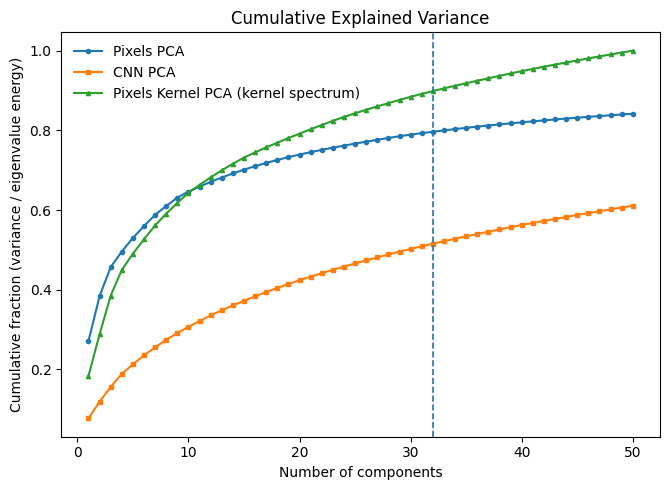

In [43]:
# Plot cumulative explained variance (PCA) and cumulative eigenvalue spectrum (Kernel PCA)
fig, ax = plt.subplots(figsize=(6.8,5.0))
xs = np.arange(1, 51)

ax.plot(xs, cum_px,    marker='o', ms=3, label='Pixels PCA')
ax.plot(xs, cum_cnn,   marker='s', ms=3, label='CNN PCA')
ax.plot(xs, cum_kpca,  marker='^', ms=3, label='Pixels Kernel PCA (kernel spectrum)')

ax.axvline(32, ls='--', lw=1.2)
ax.set_xlabel('Number of components')
ax.set_ylabel('Cumulative fraction (variance / eigenvalue energy)')
ax.set_title('Cumulative Explained Variance')
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

### 5.2 32D Classification Results

#### Accuracy, Precision, and Recall
- **Accuracy** measures the fraction of correct predictions on the test set.  

- **Precision** measures how reliable each predicted class is.  

- **Recall** measures how completely each true class is recovered.  

In [21]:
# Accuracy for each pipeline
acc_px   = accuracy_score(yte, yhat_px)
acc_cnn  = accuracy_score(yte, yhat_cnn)
acc_kpca = accuracy_score(yte, yhat_kpca)

# Recall for each pipeline
rec_px = recall_score(yte, yhat_px, average='macro')
rec_cnn = recall_score(yte, yhat_cnn, average='macro')
rec_kpca = recall_score(yte, yhat_kpca, average='macro')

# Precision for each pipeline
prec_px = precision_score(yte, yhat_px, average='macro')
prec_cnn = precision_score(yte, yhat_cnn, average='macro')
prec_kpca = precision_score(yte, yhat_kpca, average='macro')

# Metrics summary table for visualization
acc_df = pd.DataFrame({
    'Pipeline': ['Pixels → PCA(32) → LR', 'Pixels → CNN → PCA(32) → LR', 'Pixels → KPCA(32) → LR'],
    'Test Accuracy': [acc_px, acc_cnn, acc_kpca],
    'Test Recall': [rec_px, rec_cnn, rec_kpca],
    'Test Precision': [prec_px, prec_cnn, prec_kpca]
}).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)

acc_df

,Pipeline,Test Accuracy,Test Recall,Test Precision
0,Pixels → CNN → PCA(32) → LR,0.810000,0.810523,0.810816
1,Pixels → KPCA(32) → LR,0.352222,0.351196,0.351098
2,Pixels → PCA(32) → LR,0.347222,0.346572,0.342266


### 5.3 Confusion Matrix 
- A confusion matrix provides a **class-by-class breakdown** of model performance.  
- Rows represent true labels, columns represent predicted labels.  
- Diagonal values indicate correct predictions (per-class recall).  
- This visualization helps compare how pixel PCA, Kernel PCA, and CNN embeddings differ in separating similar categories.

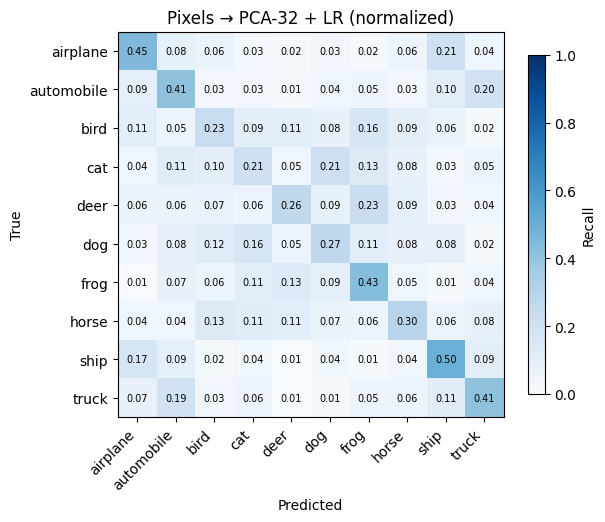

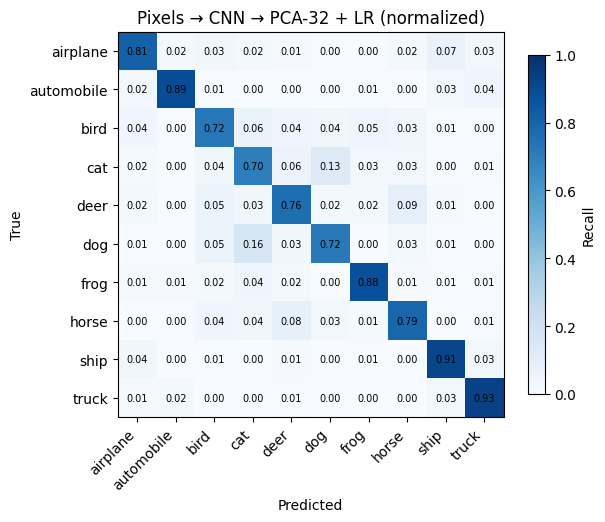

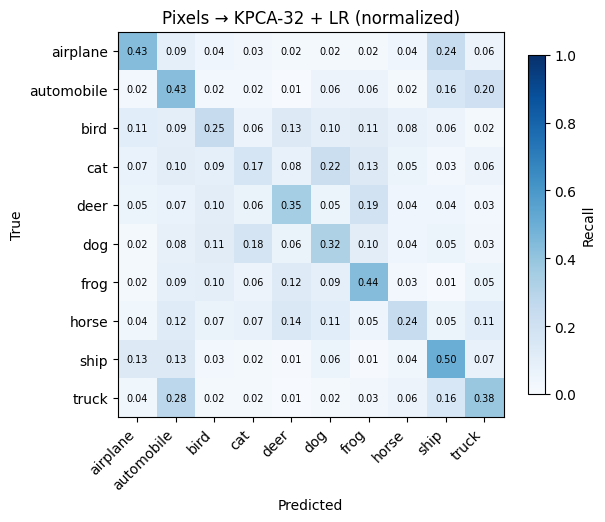

In [22]:
plot_cm(yte, yhat_px,   'Pixels → PCA-32 + LR (normalized)')
plot_cm(yte, yhat_cnn,  'Pixels → CNN → PCA-32 + LR (normalized)')
plot_cm(yte, yhat_kpca, 'Pixels → KPCA-32 + LR (normalized)')

### 5.4 50D → 3D t-SNE Visualization

- t-SNE is applied to the **50-dimensional embeddings** to generate **3D visual clusters**.  
- This step is strictly for visualization—t-SNE is not used for training or classification.  
- The goal is to visually inspect whether the embeddings capture **semantic neighborhoods**:
  - Tight clusters of the same class → good semantic structure  
  - Overlapping clusters → representations dominated by raw variance or noise  
- Comparing t-SNE plots across pipelines reveals how much each representation preserves meaning after dimensionality reduction.


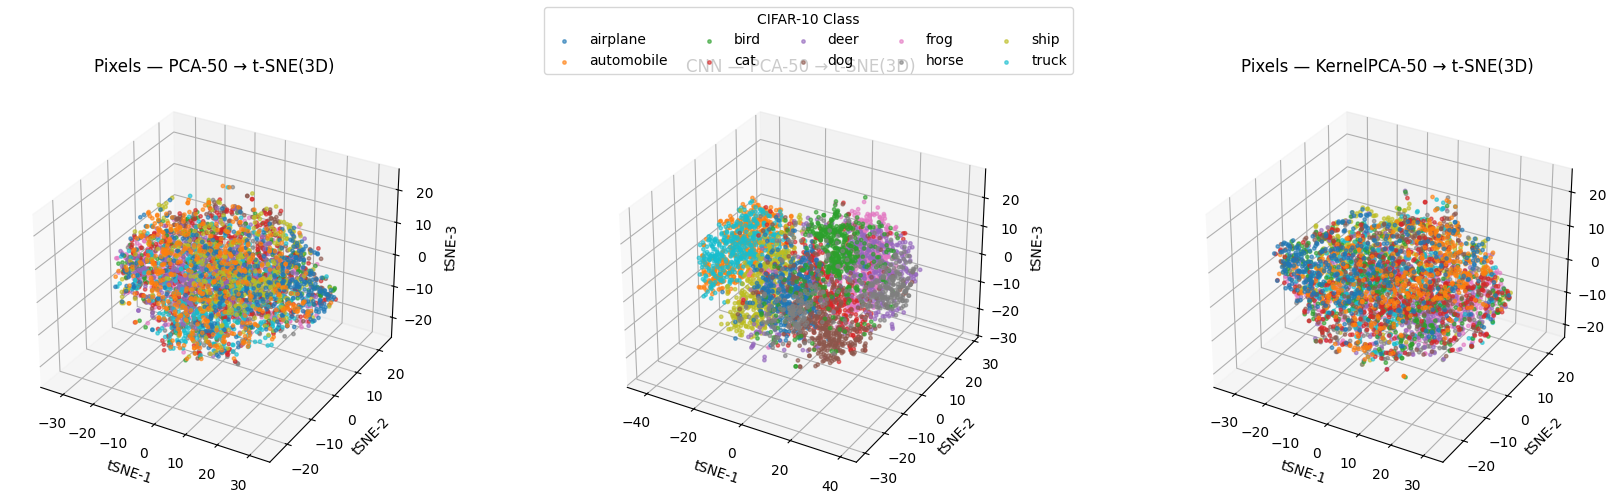

In [25]:
Z_px_tsne3   = tsne3(Xtr_px50)
Z_cnn_tsne3  = tsne3(Xtr_c50)
Z_kpca_tsne3 = tsne3(Xtr_kpca50)

# Three-panel figure
fig = plt.figure(figsize=(18,5))
axes = [fig.add_subplot(1,3,i+1, projection='3d') for i in range(3)]
titles = ['Pixels — PCA-50 → t-SNE(3D)', 'CNN — PCA-50 → t-SNE(3D)', 'Pixels — KernelPCA-50 → t-SNE(3D)']
Zs = [Z_px_tsne3, Z_cnn_tsne3, Z_kpca_tsne3]

for ax, Z, title in zip(axes, Zs, titles):
    for c in range(10):
        m = (ytr == c)
        ax.scatter(Z[m,0], Z[m,1], Z[m,2], s=6, alpha=0.6, label=CLASSES[c])
    ax.set_title(title)
    ax.set_xlabel('tSNE-1'); ax.set_ylabel('tSNE-2'); ax.set_zlabel('tSNE-3')

handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=5, title='CIFAR-10 Class')
plt.tight_layout(rect=[0,0,1,0.92])
plt.show()


**Silhouette Score (Cluster Quality in 32D)**

The **silhouette score** measures how well samples cluster within their assigned groups. It ranges from **-1 to +1**, with the following interpretation:

- +1.0 → Samples are tightly grouped with their own class and far from other classes (excellent separation).  
- 0.0 → Samples lie near class boundaries (overlap or ambiguous structure).  
- Negative values → Samples are closer to other classes than to their own class (poor separation).

,Pipeline,Silhouette (32D)
0,Pixels → CNN → PCA(32),0.047764
1,Pixels → KPCA(32),-0.036930
2,Pixels → PCA(32),-0.053602


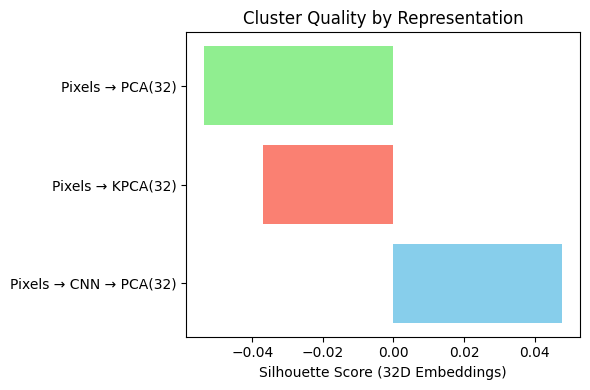

In [40]:
# --- Silhouette Scores: Evaluate cluster consistency in 32D embedding space ---
from sklearn.metrics import silhouette_score 

# Compute silhouette score for each 50D embedding type
# (Using CIFAR-10 class labels as cluster labels)
sil_px   = silhouette_score(Xtr_px32,   ytr)   # Pixel PCA
sil_kpca = silhouette_score(Xtr_kpca32, ytr)   # Kernel PCA
sil_cnn  = silhouette_score(Xtr_c32,    ytr)   # CNN → PCA

# Display results in a simple table for comparison
sil_df = pd.DataFrame({
    'Pipeline': [
        'Pixels → PCA(32)',
        'Pixels → KPCA(32)',
        'Pixels → CNN → PCA(32)'
    ],
    'Silhouette (32D)': [sil_px, sil_kpca, sil_cnn]
}).sort_values('Silhouette (32D)', ascending=False).reset_index(drop=True)

display(sil_df)

# Optional: quick horizontal bar plot for visual comparison
fig, ax = plt.subplots(figsize=(6,4))
ax.barh(sil_df['Pipeline'], sil_df['Silhouette (32D)'], color=['skyblue', 'salmon', 'lightgreen'])
ax.set_xlabel('Silhouette Score (32D Embeddings)')
ax.set_title('Cluster Quality by Representation')
plt.tight_layout()
plt.show()

## **6. Conclusions**

This project aimed to compare variance-based dimensionality reduction (PCA, Kernel PCA) against a semantic, learned representation (ResNet-18 embeddings) to evaluate whether applying dimensionality reduction directly to raw pixels can preserve meaningful and useful structure. Across all evaluations (32D classification and 50D→3D visualization), the results consistently support the initial hypothesis:
**variance alone is not sufficient to capture semantic structure**, while CNN features retain meaning even after aggressive PCA compression.

#### **Variance vs. Semantic Structure**
Both pixel-based pipelines (PCA and Kernel PCA) captured the highest cumulative variance. However, this concentration of variance did not translate into meaningful class structure. In practice, the 32D pixel embeddings failed to represent class differences in a useful way, while the CNN→PCA pipeline produced far superior features that retained semantic structure even after compression. Classification metrics (accuracy, precision, recall) reinforce this gap, and the confusion matrices make it clear: the CNN-based model exhibits a tight diagonal pattern, whereas PCA and KPCA show widespread class confusion.

#### **50D → 3D t-SNE Visualizations**
- Pixel PCA and Kernel PCA produce **highly mixed clusters**, with significant overlap across all classes.  
- CNN→PCA embeddings produce **better separated clusters**, besides the overlaps, clearly better at demonstrating class-consistent grouping in 3D space. 

Silhouette scores and t-SNE visualizations jointly confirm that CNN-based features yield the only embedding with consistently positive, class-aligned geometry, while variance-oriented PCA and Kernel PCA remain largely entangled despite their high variance/eigenvalue capture.

#### **Overall Conclusion**
The evidence strongly confirms that:
- **PCA and Kernel PCA preserve variance**, but not semantic class structure.  
- **ResNet-18 embeddings preserve semantics**, and remain robust even after PCA compression.  
- Simple linear models (like Logistic Regression) perform exceptionally well when the embedding already organizes the data meaningfully.

Thus, “**compression by meaning**” emerges as a powerful concept:  
**deep features can be heavily compressed while still retaining class-relevant structure**, something variance-based methods cannot achieve.

#### **Recommendations**
- For tasks where semantic structure matters—classification, clustering, anomaly detection—**deep feature extraction should precede dimensionality reduction**.  
- PCA/KPCA remain useful **baselines** and for understanding geometric variance but are insufficient for semantic tasks.  
- Future pipelines should default to **CNN embeddings + PCA** when interpretability and low computational cost are important.

#### **About the Author**

Hi there 👋,

My name is Leonardo Reginato, I'm a Ph.D. in the [Department of Petroleum and Geosystems Engineering](https://www.pge.utexas.edu) at [The University of Texas at Austin](https://www.utexas.edu)

My research interests lie at the intersection of machine learning and petroleum engineering, with a focus on how modern generative AI — especially diffusion-based models — can support simulation, characterization, and performance improvements in reservoir engineering. Recently, I’ve been exploring how these models might help represent geological heterogeneity across scales, translating fine-scale laboratory measurements into more realistic and efficient numerical simulations.

I’m a machine learning enthusiast who enjoys collaborative work and learning from different domains. If you’re interested in connecting or collaborating, feel free to reach out at [leonardo.reginato@austin.utexas.edu](leonardo.reginato@austin.utexas.edu)

Cheers!

Resources [GitHub](https://github.com/leonardo-reginato) | [Google Scholar](https://scholar.google.com/citations?user=VUJlvAkAAAAJ&hl=pt-BR) | [Linkedin](https://www.linkedin.com/in/leonardo-reginato/) 


#### About the Supervising Professor

Michael Pyrcz is a professor in the [Cockrell School of Engineering](https://cockrell.utexas.edu/faculty-directory/alphabetical/p), and the [Jackson School of Geosciences](https://www.jsg.utexas.edu/researcher/michael_pyrcz/), at [The University of Texas at Austin](https://www.utexas.edu/), where he researches and teaches subsurface, spatial data analytics, geostatistics, and machine learning. Michael is also,

* the principal investigator of the [Energy Analytics](https://fri.cns.utexas.edu/energy-analytics) freshmen research initiative and a core faculty in the Machine Learn Laboratory in the College of Natural Sciences, The University of Texas at Austin

* an associate editor for [Computers and Geosciences](https://www.sciencedirect.com/journal/computers-and-geosciences/about/editorial-board), and a board member for [Mathematical Geosciences](https://link.springer.com/journal/11004/editorial-board), the International Association for Mathematical Geosciences. 

Michael has written over 70 [peer-reviewed publications](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en), a [Python package](https://pypi.org/project/geostatspy/) for spatial data analytics, co-authored a textbook on spatial data analytics, [Geostatistical Reservoir Modeling](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) and author of two recently released e-books, [Applied Geostatistics in Python: a Hands-on Guide with GeostatsPy](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) and [Applied Machine Learning in Python: a Hands-on Guide with Code](https://geostatsguy.github.io/MachineLearningDemos_Book/intro.html).

All of Michael’s university lectures are available on his [YouTube Channel](https://www.youtube.com/@GeostatsGuyLectures) with links to 100s of Python interactive dashboards and well-documented workflows in over 40 repositories on his [GitHub account](https://github.com/GeostatsGuy), to support any interested students and working professionals with evergreen content. To find out more about Michael’s work and shared educational resources visit his [Website](www.michaelpyrcz.com).

#### Want to Work Together?

I hope this content is helpful to those that want to learn more about subsurface modeling, data analytics and machine learning. Students and working professionals are welcome to participate.

* Want to invite me to visit your company for training, mentoring, project review, workflow design and / or consulting? I'd be happy to drop by and work with you! 

* Interested in partnering, supporting my graduate student research or my Subsurface Data Analytics and Machine Learning consortium (co-PI is Professor John Foster)? My research combines data analytics, stochastic modeling and machine learning theory with practice to develop novel methods and workflows to add value. We are solving challenging subsurface problems!

* I can be reached at mpyrcz@austin.utexas.edu.

I'm always happy to discuss,

*Michael*

Michael Pyrcz, Ph.D., P.Eng. Professor, Cockrell School of Engineering and The Jackson School of Geosciences, The University of Texas at Austin

More Resources Available at: [Twitter](https://twitter.com/geostatsguy) | [GitHub](https://github.com/GeostatsGuy) | [Website](http://michaelpyrcz.com) | [GoogleScholar](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en&oi=ao) | [Geostatistics Book](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) | [YouTube](https://www.youtube.com/channel/UCLqEr-xV-ceHdXXXrTId5ig)  | [Applied Geostats in Python e-book](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) | [Applied Machine Learning in Python e-book](https://geostatsguy.github.io/MachineLearningDemos_Book/) | [LinkedIn](https://www.linkedin.com/in/michael-pyrcz-61a648a1)